<a href="https://colab.research.google.com/github/bmurmann/ADC-survey/blob/main/plots/energy_plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ADC Survey: FOM<sub>S</sub> Plot

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
try:
    from google.colab import files
    IN_COLAB = True
except:
    IN_COLAB = False

In [26]:
# Read latest survey data and concatenate ISSCC and VLSI data
if IN_COLAB:
    data = "https://github.com/bmurmann/ADC-survey/blob/main/xls/ADCsurvey_latest.xlsx?raw=true"
else:
    data = "../xls/ADCsurvey_latest.xlsx"
df1 = pd.read_excel(data, sheet_name='ISSCC')
df2 = pd.read_excel(data, sheet_name='VLSI')
df = pd.concat([df1, df2])

In [27]:
# Show headers of data table
print(df.keys())

Index(['YEAR', 'ID', 'TYPE', 'ARCHITECTURE', 'TECHNOLOGY', 'TITLE', 'ABSTRACT',
       'AUTHORS', 'DOI', 'LINK', 'COMMENTS', 'VSUP1 [V]', 'VSUP2 [V]',
       'VSUP3 [V]', 'Csamp [pF]', 'AREA [mm^2]', 'SNDR_lf [dB]', 'fin_hf [Hz]',
       'SNDR_hf [dB]', 'SNR [dB]', 'DR [dB]', '-THD [dB]', 'SFDR [dB]',
       'SNDR_plot [dB]', 'P [W]', 'fs [Hz]', 'OSR', 'fsnyq [Hz]',
       'fcenter [Hz]', 'P/fsnyq [pJ]', 'FOMW_lf [fJ/conv-step]',
       'FOMW_hf [fJ/conv-step]', 'FOMS_lf [dB]', 'FOMS_hf [dB]',
       'FOMW_hf/fsnyq', 'FOMS,hf+10log(fsnyq)'],
      dtype='object')


In [28]:
# Compute envelope for FOMS plot
num_avg = 5
foms_lin = 10**(df['FOMS_hf [dB]']/10)
foms_lin_largest = sorted(foms_lin)[-num_avg:]
foms_lin_asymp = np.mean(foms_lin_largest)
foms_db_asymp = 10*np.log10(foms_lin_asymp)

foms_times_fs = foms_lin * df['fsnyq [Hz]']
foms_times_fs_largest = sorted(foms_times_fs)[-num_avg:]
foms_times_fs_asymp = np.mean(foms_times_fs_largest)

f_corner = foms_times_fs_asymp/foms_lin_asymp
env_x = np.logspace(1, 12, num=300)
env_y = foms_db_asymp - 10*np.log10(np.sqrt(1+(env_x/f_corner)**2))

In [29]:
# Decent settings for a PowerPoint figure
font=16
size=(8, 5)

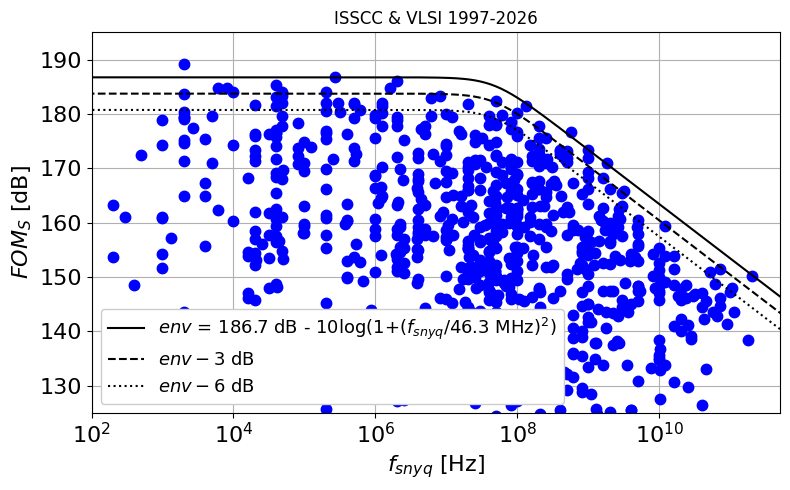

In [30]:
fig, ax = plt.subplots(figsize=size)
ax.plot(df['fsnyq [Hz]'], df['FOMS_hf [dB]'], 'b.', ms=15)
ax.plot(env_x, env_y, 'k', label='$env$ = %.1f dB - 10log(1+($f_{snyq}/$%.1f MHz$)^2)$' %(foms_db_asymp, f_corner/1e6))
ax.plot(env_x, env_y-3, 'k--', label='$env - 3$ dB')
ax.plot(env_x, env_y-6, 'k:', label='$env - 6$ dB')
ax.legend(frameon=1, loc='lower left', framealpha=1.0, fontsize=font-3)
ax.set_xscale('log')
ax.set_xlim((1e2, 500e9))
ax.set_ylim((125, 195))
plt.xticks(fontsize=font)
plt.yticks(fontsize=font)
plt.xlabel('$f_{snyq}$ [Hz]', fontsize=font)
plt.ylabel('$FOM_S$ [dB]', fontsize=font)
plt.title('ISSCC & VLSI 1997-%d' %max(df['YEAR']))
plt.grid(True)
fig.tight_layout()
plt.show()

In [31]:
# save as high-resolution png file
if IN_COLAB:
   files.download('foms_plot.png')
else:
   fig.savefig("foms_plot.png", dpi=600)

In [32]:
# save parameters as json file
data = {
    "foms_db_asymp": foms_db_asymp,
    "f_corner": f_corner,
}
file_name = "foms_plot.json"
try:
    with open(file_name, "w") as json_file:
        json.dump(data, json_file, indent=4)
    print(f"Data successfully written to {file_name}")
except IOError as e:
    print(f"Error writing to file: {e}")

Data successfully written to foms_plot.json
